# Subsetting & Filtering — getting exactly the rows and columns you asked for

01 Core Python · **▶ 02 Pandas** · 03 Cleaning · 04 Transformation · 05 Feature Engineering · 06 Regression · 07 Model Prep · 08 Case Studies

`02_Pandas_Essentials/05_subsetting_and_filtering.ipynb`

---

### In one paragraph (no jargon)

Subsetting means cutting a smaller piece out of a table: some columns, some rows, or both. Pandas gives you several overlapping ways to do it and they trip people up because they *look* similar but behave differently — one counts positions, another reads labels, a third takes a true/false test. This notebook sorts out which is which, then builds up to the conditional filtering you'll use in almost every question.

### After this notebook you can

- Select columns as a Series or as a DataFrame, and know when each is needed
- Use `.iloc` (by position) and `.loc` (by label) without mixing them up
- Filter rows with a boolean condition, and combine several conditions safely
- Use `.isin()`, `.between()` and `.str` filters instead of long chains of `or`

**Assumed knowledge:** `01_series_and_dataframes.ipynb`

### What's inside

1. Setup and first look
2. Selecting columns
3. Rows by position — .iloc
4. Rows and columns by label — .loc
5. Boolean (condition-based) filtering
6. Matching a list of values with .isin()
7. ⚡ Chained indexing and the SettingWithCopyWarning
8. Exam quick-reference

---

> **▶ Runs on its own.** The next cell is the only setup you need. It imports the
> libraries and loads the data. If the `datasets/` folder isn't where it expects,
> it rebuilds an equivalent dataset in memory so **every cell below still runs** —
> handy if you copy this single `.ipynb` somewhere else.
>
> **▶ Reading the cells.** Code comments explain *what the line does*; the text
> blocks explain *why you'd do it*. Look for these markers:
> `# WHAT:` a plain-English translation · `# WHY:` the reason it matters ·
> `# 🔧 CHANGE THIS:` the knob to turn when the exam question differs ·
> **⚡ Beyond the syllabus** = optional, higher-mark techniques.

In [1]:
# =============================================================================
# SETUP — run this cell first. It is the only cell with dependencies.
# =============================================================================
# WHAT: `import` pulls in code other people have written so we don't rewrite it.
#       The `as pd` part is a nickname, so we can type `pd` instead of `pandas`.
import pandas as pd          # tables of data (think: Excel, but programmable)
import numpy as np           # fast maths on whole columns at once
import matplotlib.pyplot as plt   # charts
import warnings

warnings.filterwarnings('ignore')          # hide version-upgrade notices, keeps output readable
pd.set_option('display.max_columns', 50)   # don't hide columns behind "..."
pd.set_option('display.width', 160)
import os
import seaborn as sns
sns.set_theme(style="whitegrid")

def find_datasets_folder(start=None):
    """Walk upwards from this notebook looking for the shared `datasets/` folder.

    WHY: it means the notebook works whether you opened it from its own folder,
    from the top of the notes, or from anywhere else on your machine.
    """
    here = os.path.abspath(start or os.getcwd())
    for _ in range(6):                       # look up to 6 folders up
        candidate = os.path.join(here, 'datasets')
        if os.path.isdir(candidate):
            return candidate
        parent = os.path.dirname(here)
        if parent == here:
            break
        here = parent
    return None

def dataset_path(filename, rebuild=None):
    """Return a real path to `filename`, materialising a temp copy if it's missing.

    WHY: a few pandas tools (pd.ExcelFile, pd.read_sql) need an actual file path
         rather than a DataFrame, so the fallback has to be written to disk.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    if rebuild is None:
        raise FileNotFoundError(filename)
    import tempfile
    tmp = os.path.join(tempfile.mkdtemp(prefix='bda_'), filename)
    frame = rebuild()
    (frame.to_excel(tmp, index=False) if filename.lower().endswith(('.xlsx', '.xls'))
     else frame.to_csv(tmp, index=False))
    print(f"'{filename}' not found -> wrote a rebuilt copy to {tmp}")
    return tmp

def load_data(filename, rebuild=None, **read_kwargs):
    """Load `filename` from the shared datasets folder, or rebuild it in memory.

    WHAT: tries to read the real file; if it can't find it, calls `rebuild()`
          which recreates a dataset with the same columns and behaviour.
    WHY:  guarantees this notebook runs even if the CSV goes missing.
    """
    folder = find_datasets_folder()
    if folder:
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            reader = pd.read_excel if filename.lower().endswith(('.xlsx', '.xls')) else pd.read_csv
            print(f"Loaded '{filename}' from {folder}")
            return reader(path, **read_kwargs)
    if rebuild is None:
        raise FileNotFoundError(f"Could not find {filename} and no fallback was supplied.")
    print(f"'{filename}' not found on disk -> rebuilding an equivalent dataset in memory.")
    built = rebuild()
    if 'chunksize' in read_kwargs:            # keep chunked reads working on the fallback path
        size = read_kwargs['chunksize']
        return (built.iloc[i:i + size] for i in range(0, len(built), size))
    return built

def rebuild_customer_data():
    """Exact copy of customer_data.csv, embedded so this notebook never needs the file."""
    import io
    csv_text = """Customer_ID,Age,Gender,Income,Purchase_Amount,Region
1,55.0,Male,70000.0,2400.0,West
2,45.0,Male,65000.0,1900.0,North
3,31.0,Male,30000.0,2400.0,East
4,59.0,Female,50000.0,1400.0,
5,24.0,Female,70000.0,4000.0,East
6,37.0,,20000.0,3900.0,West
7,55.0,Male,25000.0,3800.0,South
8,35.0,Female,70000.0,2200.0,West
9,39.0,Female,,2300.0,East
10,27.0,Male,,2100.0,West
11,27.0,Female,75000.0,4400.0,North
12,40.0,Female,25000.0,1700.0,North
13,52.0,Female,65000.0,1800.0,North
14,56.0,Male,35000.0,3400.0,East
15,40.0,Male,70000.0,,West
16,19.0,Female,25000.0,600.0,West
17,38.0,Female,,1900.0,North
18,18.0,Male,,2600.0,West
19,40.0,Male,50000.0,1400.0,South
20,46.0,,60000.0,1500.0,South
21,54.0,Male,65000.0,1300.0,North
22,18.0,Female,70000.0,3500.0,West
23,37.0,Female,75000.0,1900.0,North
24,49.0,Female,75000.0,1100.0,East
25,28.0,Female,70000.0,4100.0,West
26,38.0,Male,20000.0,1500.0,North
27,41.0,Female,75000.0,2700.0,East
28,43.0,Female,25000.0,3100.0,South
29,58.0,Male,20000.0,1100.0,South
30,44.0,Male,25000.0,3100.0,East
31,32.0,,45000.0,3900.0,South
32,31.0,Female,,2900.0,East
33,19.0,Male,60000.0,1100.0,East
34,53.0,,50000.0,3100.0,East
35,23.0,,75000.0,3100.0,West
36,37.0,Female,60000.0,4000.0,East
37,25.0,Female,60000.0,4400.0,East
38,55.0,Male,60000.0,3900.0,East
39,34.0,Male,20000.0,3000.0,South
40,20.0,Female,25000.0,2000.0,South
41,41.0,Female,55000.0,1200.0,West
42,30.0,Female,45000.0,3600.0,East
43,25.0,Male,30000.0,2300.0,South
44,42.0,Female,60000.0,1600.0,East
45,18.0,Female,35000.0,3100.0,South
46,36.0,,20000.0,3200.0,West
47,44.0,Female,75000.0,1600.0,North
48,23.0,Female,65000.0,4900.0,South
49,24.0,Female,75000.0,3800.0,South
50,51.0,Male,50000.0,900.0,East
51,30.0,,30000.0,2100.0,West
52,33.0,,55000.0,800.0,North
53,52.0,Male,35000.0,2800.0,West
54,56.0,Male,75000.0,500.0,North
55,20.0,Female,55000.0,1300.0,West
56,18.0,Male,30000.0,3300.0,North
57,22.0,,60000.0,4800.0,North
58,58.0,Male,35000.0,800.0,East
59,20.0,Male,55000.0,3600.0,
60,45.0,Female,50000.0,,West
61,34.0,Male,25000.0,2100.0,East
62,42.0,Male,,3500.0,West
63,50.0,Female,25000.0,1400.0,North
64,26.0,Female,30000.0,2400.0,
65,52.0,Male,20000.0,2900.0,East
66,30.0,Female,,2800.0,West
67,47.0,Female,45000.0,2500.0,West
68,31.0,Female,50000.0,3000.0,West
69,24.0,Male,45000.0,1600.0,East
70,30.0,Female,35000.0,3600.0,East
71,39.0,,70000.0,3700.0,West
72,56.0,Female,,4400.0,South
73,37.0,,45000.0,3800.0,
74,32.0,Male,75000.0,,West
75,34.0,Male,45000.0,2400.0,North
76,40.0,Female,55000.0,900.0,West
77,42.0,Female,25000.0,3100.0,East
78,41.0,Female,55000.0,2000.0,West
79,57.0,Male,,800.0,West
80,45.0,Female,,3400.0,North
81,31.0,Female,30000.0,800.0,East
82,,Female,55000.0,4100.0,West
83,41.0,Male,40000.0,600.0,South
84,23.0,,75000.0,2600.0,East
85,25.0,Female,65000.0,4000.0,South
86,40.0,Male,25000.0,4000.0,East
87,,Female,,1300.0,East
88,24.0,Female,30000.0,1300.0,East
89,40.0,,70000.0,2200.0,South
90,27.0,Male,75000.0,2000.0,East
91,33.0,Female,55000.0,2400.0,North
92,24.0,Female,25000.0,1700.0,North
93,51.0,,70000.0,1200.0,North
94,51.0,Male,55000.0,4900.0,North
95,49.0,Male,45000.0,,East
96,21.0,Male,70000.0,4800.0,East
97,58.0,Male,30000.0,1600.0,West
98,55.0,Female,25000.0,700.0,North
99,57.0,Male,60000.0,,West
100,44.0,Male,35000.0,4300.0,West
101,23.0,Female,35000.0,3500.0,South
102,25.0,,25000.0,3700.0,West
103,24.0,Male,70000.0,3100.0,
104,28.0,Male,55000.0,3400.0,South
105,50.0,Female,30000.0,1100.0,South
106,49.0,Male,65000.0,4200.0,West
107,39.0,Male,35000.0,2900.0,West
108,40.0,Male,30000.0,3700.0,North
109,53.0,Male,35000.0,600.0,West
110,51.0,Female,45000.0,1500.0,West
111,56.0,Male,55000.0,,West
112,38.0,Female,45000.0,4700.0,West
113,43.0,Female,75000.0,800.0,West
114,51.0,Male,35000.0,3300.0,North
115,,Male,60000.0,3300.0,South
116,51.0,Male,60000.0,2000.0,East
117,53.0,Female,45000.0,2600.0,West
118,30.0,Male,60000.0,1800.0,South
119,19.0,Male,35000.0,4000.0,East
120,,Female,25000.0,2400.0,East
121,21.0,Male,45000.0,1700.0,East
122,42.0,Male,75000.0,500.0,West
123,30.0,Male,65000.0,1400.0,West
124,55.0,Male,65000.0,4200.0,East
125,43.0,Female,20000.0,4100.0,East
126,25.0,Male,70000.0,3700.0,South
127,31.0,Female,55000.0,4100.0,East
128,31.0,Male,60000.0,3700.0,South
129,42.0,Female,60000.0,2100.0,South
130,58.0,Male,70000.0,3300.0,East
131,29.0,Male,,1800.0,North
132,48.0,,75000.0,3000.0,South
133,55.0,Female,40000.0,3700.0,East
134,48.0,Female,45000.0,4100.0,South
135,20.0,Male,75000.0,3600.0,South
136,46.0,Male,50000.0,2700.0,West
137,53.0,Male,60000.0,1800.0,East
138,39.0,Female,55000.0,3300.0,North
139,55.0,Male,20000.0,4500.0,West
140,31.0,Female,65000.0,2000.0,East
141,59.0,Male,60000.0,800.0,West
142,45.0,,20000.0,3200.0,East
143,52.0,Female,35000.0,700.0,
144,29.0,Female,75000.0,1300.0,West
145,48.0,Male,35000.0,2000.0,West
146,23.0,Male,40000.0,1300.0,West
147,38.0,Female,25000.0,2000.0,North
148,44.0,Male,50000.0,2300.0,South
149,18.0,Male,75000.0,2700.0,West
150,58.0,,,800.0,East
151,22.0,Female,40000.0,3700.0,West
152,44.0,Male,30000.0,900.0,North
153,44.0,Male,,500.0,East
154,36.0,Male,45000.0,1600.0,South
155,46.0,Female,55000.0,4600.0,East
156,27.0,Male,75000.0,4600.0,East
157,44.0,Male,30000.0,1400.0,East
158,41.0,Male,30000.0,2600.0,East
159,55.0,Male,40000.0,1900.0,East
160,49.0,Female,70000.0,3400.0,South
161,,Male,25000.0,1400.0,West
162,43.0,,75000.0,1900.0,North
163,29.0,Male,70000.0,1100.0,East
164,57.0,Male,40000.0,700.0,East
165,19.0,Male,45000.0,4300.0,West
166,55.0,Male,65000.0,700.0,East
167,22.0,,60000.0,2800.0,West
168,24.0,Female,60000.0,600.0,
169,43.0,Female,25000.0,3500.0,South
170,25.0,Female,45000.0,600.0,South
171,53.0,Male,25000.0,3000.0,South
172,49.0,Female,75000.0,3200.0,South
173,58.0,Male,75000.0,3500.0,East
174,40.0,Female,20000.0,2200.0,West
175,31.0,Male,70000.0,2400.0,North
176,48.0,Male,60000.0,800.0,North
177,48.0,Male,30000.0,2100.0,South
178,40.0,Male,70000.0,3100.0,West
179,57.0,Male,50000.0,4500.0,East
180,28.0,Male,75000.0,2500.0,North
181,55.0,,55000.0,2400.0,West
182,18.0,Male,45000.0,900.0,West
183,19.0,Male,,,North
184,53.0,Female,25000.0,800.0,East
185,33.0,Female,75000.0,4400.0,West
186,18.0,Male,70000.0,1500.0,South
187,18.0,Female,55000.0,2900.0,North
188,44.0,Female,70000.0,4900.0,North
189,39.0,Male,,3700.0,North
190,53.0,,55000.0,1700.0,West
191,48.0,Female,50000.0,2900.0,West
192,49.0,Male,,4800.0,North
193,,Male,40000.0,3000.0,South
194,35.0,,35000.0,1200.0,North
195,18.0,Female,40000.0,2900.0,North
196,42.0,Female,60000.0,2500.0,West
197,48.0,Female,70000.0,3300.0,South
198,22.0,Female,75000.0,4600.0,South
199,48.0,,75000.0,2000.0,South
200,20.0,,75000.0,2900.0,East"""
    return pd.read_csv(io.StringIO(csv_text))

print("Setup complete. pandas", pd.__version__, "| numpy", np.__version__)

Setup complete. pandas 3.0.2 | numpy 2.4.4


# Subsetting in Pandas — Selecting Exactly the Rows & Columns You Need

**Dataset:** `customer_data.csv` — 200 customer records (Age, Gender, Income, Purchase_Amount, Region).

"Subsetting" just means pulling out a smaller piece of a DataFrame — specific columns, specific rows, or both — based on position, label, or a condition. Pandas gives you several overlapping ways to do this, each with a different trade-off between speed, readability, and flexibility. This notebook builds up from the simplest cases to the techniques you'll actually reach for in real analysis work.

## 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="crest")
plt.rcParams['figure.dpi'] = 100

df = load_data('customer_data.csv', rebuild=rebuild_customer_data)
print(f"Shape: {df.shape}")
df.head()

Loaded 'customer_data.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
Shape: (200, 6)


,Customer_ID,Age,Gender,Income,Purchase_Amount,Region
0,1,55.0,Male,70000.0,2400.0,West
1,2,45.0,Male,65000.0,1900.0,North
2,3,31.0,Male,30000.0,2400.0,East
3,4,59.0,Female,50000.0,1400.0,NaN
4,5,24.0,Female,70000.0,4000.0,East


## 2. Selecting columns

In [3]:
# Single column -> returns a Series
ages = df['Age']
print(type(ages), '\n')

# Multiple columns -> pass a LIST of names, returns a DataFrame
subset_cols = df[['Customer_ID', 'Age', 'Region']]
subset_cols.head()

<class 'pandas.Series'> 



,Customer_ID,Age,Region
0,1,55.0,West
1,2,45.0,North
2,3,31.0,East
3,4,59.0,NaN
4,5,24.0,East


## 3. Selecting rows by POSITION — `.iloc[]`
`.iloc` is purely integer-position based, like classic Python list indexing (0-indexed, end-exclusive on slices).

In [4]:
print("First 3 rows, all columns:")
# Remember: .iloc slices are END-EXCLUSIVE — 0:3 gives rows 0, 1 and 2 only.
display(df.iloc[0:3])

print("\nRow at position 5, columns at positions 1 through 3:")
display(df.iloc[5, 1:4])

print("\nEvery other row from the first 10 (position-based step slicing):")
display(df.iloc[0:10:2])

First 3 rows, all columns:


,Customer_ID,Age,Gender,Income,Purchase_Amount,Region
0,1,55.0,Male,70000.0,2400.0,West
1,2,45.0,Male,65000.0,1900.0,North
2,3,31.0,Male,30000.0,2400.0,East



Row at position 5, columns at positions 1 through 3:


Age          37.0
Gender        NaN
Income    20000.0
Name: 5, dtype: object


Every other row from the first 10 (position-based step slicing):


,Customer_ID,Age,Gender,Income,Purchase_Amount,Region
0,1,55.0,Male,70000.0,2400.0,West
2,3,31.0,Male,30000.0,2400.0,East
4,5,24.0,Female,70000.0,4000.0,East
6,7,55.0,Male,25000.0,3800.0,South
8,9,39.0,Female,NaN,2300.0,East


## 4. Selecting rows/columns by LABEL — `.loc[]`
`.loc` uses the actual index labels and column names — and unlike `.iloc`, label-based slices are **end-inclusive**.

In [5]:
print("Rows labeled 0 through 3 (inclusive!), specific named columns:")
# …whereas .loc slices are END-INCLUSIVE — 0:3 gives rows 0, 1, 2 AND 3.
display(df.loc[0:3, ['Customer_ID', 'Age', 'Income']])

print("\nUsing .loc with a boolean condition directly:")
display(df.loc[df['Age'] > 50, ['Customer_ID', 'Age', 'Region']].head())

Rows labeled 0 through 3 (inclusive!), specific named columns:


,Customer_ID,Age,Income
0,1,55.0,70000.0
1,2,45.0,65000.0
2,3,31.0,30000.0
3,4,59.0,50000.0



Using .loc with a boolean condition directly:


,Customer_ID,Age,Region
0,1,55.0,West
3,4,59.0,NaN
6,7,55.0,South
12,13,52.0,North
13,14,56.0,East


## 5. Boolean (condition-based) filtering
The workhorse of real-world subsetting: build a True/False mask from a condition, then use it to keep only matching rows.

In [6]:
high_earners = df[df['Income'] > 60000]
print(f"Customers earning more than 60,000: {len(high_earners)} of {len(df)}")

# Combine multiple conditions with & (and) / | (or) -- note the REQUIRED parentheses
# around each condition, since Python's operator precedence would otherwise misparse this.
# 🔧 CHANGE THIS: swap the column names and thresholds for the exam's question.
# The BRACKETS around each condition are compulsory, and & means AND (not the word 'and').
west_high_earners = df[(df['Region'] == 'West') & (df['Income'] > 50000)]
print(f"West region AND income > 50,000: {len(west_high_earners)} rows")

not_east = df[~(df['Region'] == 'East')]  # ~ negates a boolean mask
print(f"Everyone EXCEPT the East region: {len(not_east)} rows")

Customers earning more than 60,000: 56 of 200
West region AND income > 50,000: 28 rows
Everyone EXCEPT the East region: 144 rows


## 6. `.isin()` — matching against a list of allowed values
Cleaner than chaining several `==` conditions with `|` when you have more than 2-3 acceptable values.

In [7]:
coastal_regions = df[df['Region'].isin(['West', 'East'])]
print(f"Coastal regions (West or East): {len(coastal_regions)} rows")
coastal_regions['Region'].value_counts()

Coastal regions (West or East): 115 rows


Region
West    59
East    56
Name: count, dtype: int64

## 7. `.query()` — filtering with a readable string expression
For complex, multi-condition filters, `.query()` often reads more like plain English than a chain of bracket-and-ampersand boolean masks.

In [8]:
result = df.query("Age > 30 and Income > 40000 and Region == 'West'")
print(f"Query result: {len(result)} rows")
result.head()

Query result: 27 rows


,Customer_ID,Age,Gender,Income,Purchase_Amount,Region
0,1,55.0,Male,70000.0,2400.0,West
7,8,35.0,Female,70000.0,2200.0,West
14,15,40.0,Male,70000.0,NaN,West
40,41,41.0,Female,55000.0,1200.0,West
59,60,45.0,Female,50000.0,NaN,West


## 8. `.at[]` / `.iat[]` — fast single-value access
When you need exactly **one** cell's value (not a row or column), `.at`/`.iat` are faster than `.loc`/`.iloc` since they skip the overhead of building a full Series/DataFrame just to return one number.

In [9]:
value_by_label = df.at[10, 'Income']      # label-based single value
value_by_position = df.iat[10, 3]          # position-based single value (column 3 = Income)
print(f".at[10, 'Income']  -> {value_by_label}")
print(f".iat[10, 3]        -> {value_by_position}")
print(f"Same value either way: {value_by_label == value_by_position}")

.at[10, 'Income']  -> 75000.0
.iat[10, 3]        -> 75000.0
Same value either way: True


## 9. Subsetting by data type — `select_dtypes()`
Useful when you want to apply an operation (like scaling, or a correlation matrix) to *only* the numeric columns, without hand-listing them.

In [10]:
numeric_only = df.select_dtypes(include='number')
categorical_only = df.select_dtypes(include='object')
print(f"Numeric columns: {list(numeric_only.columns)}")
print(f"Categorical (object) columns: {list(categorical_only.columns)}")

Numeric columns: ['Customer_ID', 'Age', 'Income', 'Purchase_Amount']
Categorical (object) columns: ['Gender', 'Region']


## 10. Putting it together: visualizing a subset

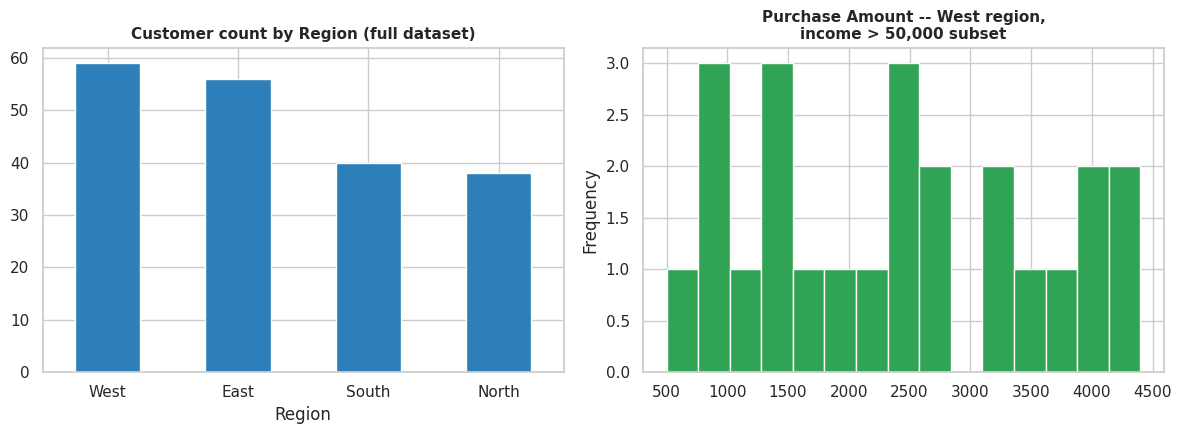

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

df['Region'].value_counts().plot(kind='bar', ax=axes[0], color='#2c7fb8')
axes[0].set_title('Customer count by Region (full dataset)', fontweight='bold', fontsize=11)
axes[0].tick_params(axis='x', rotation=0)

west_high_earners['Purchase_Amount'].plot(kind='hist', bins=15, ax=axes[1], color='#31a354', edgecolor='white')
axes[1].set_title('Purchase Amount -- West region,\nincome > 50,000 subset', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

## Key takeaways

| Technique | Selects by... | Best for |
|---|---|---|
| `df['col']` / `df[['a','b']]` | Column name(s) | Simple column selection |
| `.iloc[]` | Integer position | Position-based slicing, unknown/irrelevant labels |
| `.loc[]` | Label (index/column name) | Label-based access, combining with conditions |
| Boolean masks (`df[condition]`) | A True/False condition | General-purpose row filtering |
| `.isin([...])` | Membership in a list | Matching against several allowed values |
| `.query("...")` | A readable string expression | Complex, multi-condition filters |
| `.at[] / .iat[]` | Single label / position | Fast single-value lookups |
| `.select_dtypes()` | Column data type | Grabbing all numeric/categorical columns at once |

**Performance note:** for single-value lookups, prefer `.at`/`.iat` over `.loc`/`.iloc`; for whole-column boolean filtering, vectorized conditions (as used throughout this notebook) are dramatically faster than looping over rows with `.iterrows()` — always prefer the vectorized approach.

### ⚡ Beyond the syllabus — chained indexing and the `SettingWithCopyWarning`

This is the single most confusing warning in pandas, and it appears in almost everyone's exam output. It happens when you filter a table and then try to change the result: pandas can't tell whether you meant to edit a *copy* or the *original*, so it warns and may silently do nothing. The fix is one word — `.copy()` — or one habit: do the selection and the assignment in a single `.loc[]`.

In [12]:
df = load_data('customer_data.csv', rebuild=rebuild_customer_data)

# ---- THE PROBLEM ------------------------------------------------------------
# Two steps: filter, then assign. Pandas doesn't know if `west` is a view or a copy.
west = df[df['Region'] == 'West']
import warnings
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    west['Discount'] = 0.10                       # <- the risky line
    if caught:
        print("Warning raised:", str(caught[0].message).split('\n')[0][:110], "...")
    else:
        print("(No warning on this pandas version — but the pattern is still unsafe.)")

# ---- FIX 1: say explicitly that you want a copy -----------------------------
west_safe = df[df['Region'] == 'West'].copy()     # <- one word, problem gone
west_safe['Discount'] = 0.10
print("\nFix 1 — .copy() then edit freely:", west_safe['Discount'].head(2).tolist())

# ---- FIX 2: edit the ORIGINAL in one .loc[] step ----------------------------
# Read it as: for the rows matching this condition, set this column.
df.loc[df['Region'] == 'West', 'Discount'] = 0.10
df.loc[df['Region'] != 'West', 'Discount'] = 0.00
print("Fix 2 — single-step .loc assignment:")
print(df.groupby('Region')['Discount'].first().to_string())

print("""
THE RULE
  Selecting only?              df[df.Region == 'West']            fine
  Selecting THEN editing?      df[...].copy()                     safe
  Editing the original?        df.loc[mask, 'col'] = value        best
  Never:                       df[df.Region == 'West']['col'] = 1 <- silently does nothing""")

Loaded 'customer_data.csv' from /home/claude/work/build/Python-BDA-Complete-Notes/datasets
(No warning on this pandas version — but the pattern is still unsafe.)

Fix 1 — .copy() then edit freely: [0.1, 0.1]
Fix 2 — single-step .loc assignment:
Region
East     0.0
North    0.0
South    0.0
West     0.1

THE RULE
  Selecting only?              df[df.Region == 'West']            fine
  Selecting THEN editing?      df[...].copy()                     safe
  Editing the original?        df.loc[mask, 'col'] = value        best
  Never:                       df[df.Region == 'West']['col'] = 1 <- silently does nothing


### ⚡ Beyond the syllabus — `.at`, `.iat` and `.filter()` — the specialist selectors

Three more selectors worth a line each. `.at` / `.iat` fetch a **single cell** far faster than `.loc` / `.iloc` (they skip all the slice-handling machinery). `.filter()` selects **columns by name pattern** — invaluable when a file has forty columns and you want the six that start with `sales_`.

In [13]:
# .at / .iat — single cell, fastest route
print("df.at[0, 'Age']  ->", df.at[0, 'Age'], "  (by label)")
print("df.iat[0, 1]     ->", df.iat[0, 1], "  (by position)")

# .filter() — pick columns by pattern rather than typing every name
print("\nColumns containing 'come':", list(df.filter(like='come').columns))
print("Columns matching a regex  :", list(df.filter(regex='^(Age|Income)$').columns))

# .filter(items=) is a safe way to select columns that may not all exist
wanted = ['Age', 'Income', 'Loyalty_Score']        # Loyalty_Score isn't in the file
print("filter(items=) skips missing ones:", list(df.filter(items=wanted).columns))
print("…whereas df[wanted] would raise a KeyError.")

# Sampling — quick sanity checks on a big table
print("\nRandom 3 rows (random_state fixes the draw so it's reproducible):")
display(df.sample(3, random_state=42))
print("A 1% sample:", df.sample(frac=0.01, random_state=42).shape)

df.at[0, 'Age']  -> 55.0   (by label)
df.iat[0, 1]     -> 55.0   (by position)

Columns containing 'come': ['Income']
Columns matching a regex  : ['Age', 'Income']
filter(items=) skips missing ones: ['Age', 'Income']
…whereas df[wanted] would raise a KeyError.

Random 3 rows (random_state fixes the draw so it's reproducible):


,Customer_ID,Age,Gender,Income,Purchase_Amount,Region,Discount
95,96,21.0,Male,70000.0,4800.0,East,0.0
15,16,19.0,Female,25000.0,600.0,West,0.1
30,31,32.0,NaN,45000.0,3900.0,South,0.0


A 1% sample: (2, 7)


---

## Exam quick-reference

| To do this | Write this |
|---|---|
| One column (Series) | `df['Age']` |
| Several columns | `df[['Age', 'Income']]` |
| Columns by pattern | `df.filter(like='sales_')` |
| Rows by position | `df.iloc[0:3]` (end-exclusive) |
| Rows by label | `df.loc[0:3]` (end-inclusive) |
| Row and column together | `df.loc[5, 'Age']` · `df.iloc[5, 1]` |
| Single cell, fastest | `df.at[5, 'Age']` |
| Filter on a condition | `df[df['Age'] > 50]` |
| Two conditions | `df[(a > 1) & (b == 'X')]` |
| Either condition | `df[(a > 1) | (b == 'X')]` |
| Not this | `df[~(df['Region'] == 'East')]` |
| One of several values | `df[df['Region'].isin(['N','W'])]` |
| Within a range | `df[df['Age'].between(25, 40)]` |
| Text contains | `df[df['City'].str.contains('Delhi')]` |
| Edit matching rows | `df.loc[mask, 'col'] = value` |
| Random rows | `df.sample(5, random_state=42)` |

### Adapting this in the exam

- 'Rows where X and Y' → one mask per condition, joined with `&`.
- 'The first/last N rows' → `.head(N)` / `.tail(N)`, not `.iloc` arithmetic.
- 'Rows 5 to 10' → decide first whether the question means positions (`.iloc`) or labels (`.loc`).
- 'Any of these categories' → `.isin([...])` rather than a chain of `|`.

### Traps that cost marks

- `.iloc[0:3]` gives 3 rows; `.loc[0:3]` gives 4. The label version includes the endpoint.
- Use `&`, `|`, `~` — never `and`, `or`, `not` — and bracket every condition.
- `df[mask]['col'] = x` fails silently. Use `df.loc[mask, 'col'] = x`.
- Filtering then editing without `.copy()` triggers `SettingWithCopyWarning` — and may not apply your change.
- After filtering, the index has gaps: `.iloc[0]` works, `.loc[0]` may raise `KeyError`.
- `.str` methods only work on text columns. On a numeric column you get `AttributeError` — check `df.dtypes`.